This compulsory assignment will train, fine-tune and evaluate a Random Forest classifier on the MNIST dataset.

Steps:
1. Import libraries
2. Load the dataset
3. Inspect and understand the data
4. Prepare the data
5. Train a baseline Random Forest model
6. Fine-tune the model
7. Evaluate the final model on the test set
8. Summarize and discuss the results

## 1. Import libraries

In [20]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import numpy as np
import matplotlib.pyplot as plt


## 2. Load Dataset

In [21]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

## 3. Inspect and understand the

- Check Shape of features and labels
- Check Target labels
- Convert labels dtype from object to integer
- Check class distribution
- Check missing values
- Check pixel value range
- Visualize a few samples

### Check Shape of features and labels

In [22]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X dtype:", X.dtype)
print("y dtype:", y.dtype)
print(type(X), type(y))

X shape: (70000, 784)
y shape: (70000,)
X dtype: int64
y dtype: object
<class 'numpy.ndarray'> <class 'numpy.ndarray'>


### Check target labels

In [23]:
print("Unique labels:", np.unique(y))

Unique labels: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


### Convert labels dtype from object to integer (data cleaning)

In [24]:
y = y.astype(int)
print("Unique labels:", np.unique(y))

Unique labels: [0 1 2 3 4 5 6 7 8 9]


### Check class distribution

In [25]:
unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Digit {label}: {count}")

Digit 0: 6903
Digit 1: 7877
Digit 2: 6990
Digit 3: 7141
Digit 4: 6824
Digit 5: 6313
Digit 6: 6876
Digit 7: 7293
Digit 8: 6825
Digit 9: 6958


### Check missing values

In [26]:
print("Missing values in X:", np.isnan(X).sum())
print("Missing values in y:", np.isnan(y).sum() if np.issubdtype(y.dtype, np.number) else "Check not needed for non-numeric y")

Missing values in X: 0
Missing values in y: 0


### Check pixel value range

In [27]:
print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())
print("Mean pixel value:", X.mean())

Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value: 33.385964741253645


### Visualize a few samples

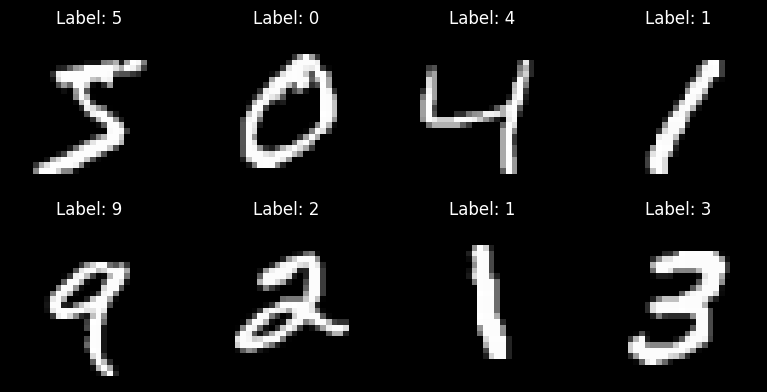

In [28]:
plt.figure(figsize=(8, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {y[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

### Results

The inspection confirmed that the **MNIST** dataset contains **70,000 images**, with each image represented by **784 features**. This corresponds to images of size **28 × 28 pixels**, resulting in **784 pixel values** per sample. The target variable contains **70,000 labels**, representing the digit classes **0 to 9**.

The feature values range from **0 to 255**, where **0 corresponds to black** and 2**55 corresponds to white**, with intermediate values representing shades of gray. This is consistent with grayscale image data.

No missing values were detected in the feature matrix. In addition, the class distribution was found to be reasonably balanced across all ten digit classes, indicating that the dataset is suitable for a classification task.

Since the target labels were initially loaded as objects, they were converted to integers before proceeding to the data preparation stage.




## 4. Prepare the data

### Splitting the dataset


In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [30]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (56000, 784)
X_test: (14000, 784)
y_train: (56000,)
y_test: (14000,)


### Results
Since the target labels had already been converted from **strings** to **integers** in the previous step, and the earlier inspection did not reveal any additional cleaning requirements, the main data preparation step was to split the dataset into **training** and **test** sets.

An **80/20 split** was applied, with 80% of the data used for training and 20% reserved for final testing. **Stratified sampling** was used to preserve the class distribution across both sets.

No **feature scaling** was applied, as **Random Forest** is a **tree-based algorithm** and does not generally require scaled input features.

## 5. Train & Fine-tune a Random Forest model

In [40]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

params = {'max_depth': list(range(1, 11)), 'max_leaf_nodes': [10, 20, 30], 'n_estimators': [10, 20, 30]}

grid_search = GridSearchCV(estimator=rf, param_grid=params, cv=5, n_jobs=-1)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [1, 2, ...], 'max_leaf_nodes': [10, 20, ...], 'n_estimators': [10, 20, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : th

### Note

**RandomForestClassifier** was used because the assignment specifically requires a R**andom Forest classifier**. **Gradient Boosting** is also an ensemble tree method, but it is a different **algorithm** and therefore not the correct primary model for this task.

**GridSearchCV** was used to fine-tune the model by testing multiple **hyperparameter** combinations and evaluating them with **cross-validation**. This makes it possible to identify the best-performing parameter settings for the **Random Forest classifier** in a systematic and reliable way.

## 7. Evaluate the final model on the test set

## 8. Summarize and discuss the results